# Genome-wide kinship

How do PLINK and KING turn genome-wide identity by state (IBS) into identity by descent (IBD), and when do they agree?

## Start from first principles

The **kinship coefficient** $\phi_{ij}$ is the probability that one random allele from person $i$ and one random allele from person $j$ are IBD.

Local IBD asks where a shared segment lies. Genome-wide kinship asks for its average over the genome. At one marker, an IBS match may be accidental. Across many markers, accidental matches approach a predictable baseline; relatives remain more similar because they inherited some of the same ancestral DNA.

## 1. Why averaging works

Start with one haploid copy from each person and 12 independent markers. Let the allele frequency be $p=1/2$ at every marker. Two unrelated copies match by chance with probability

$$
c=p^2+(1-p)^2=\frac12.
$$

Suppose a fraction $q$ of the two copies is IBD. The alleles must match there. They match with probability $c$ elsewhere. Therefore

$$
P(\mathrm{IBS})=q+(1-q)c,
\qquad
q=\frac{P(\mathrm{IBS})-c}{1-c}.
$$

The IBD states below are shown only to check the example. Real genotype data contain the match pattern, not the hidden ancestry state.

In [1]:
marker <- seq_len(12)

unrelated_match <- c(1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1)
related_ibd_truth <- c(1, 1, 1, 1, rep(0, 8))
related_match <- c(1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0)

toy_data <- data.frame(
  marker,
  unrelated_IBS_match = unrelated_match,
  related_IBS_match = related_match,
  related_IBD_truth_for_checking = related_ibd_truth
)
toy_data

chance_match <- 0.5
match_rate <- c(mean(unrelated_match), mean(related_match))
estimated_ibd_fraction <- (match_rate - chance_match) / (1 - chance_match)

toy_summary <- data.frame(
  pair = c("Unrelated", "Related"),
  matches = c(sum(unrelated_match), sum(related_match)),
  markers = length(marker),
  match_rate,
  estimated_IBD_fraction = estimated_ibd_fraction
)
toy_summary

stopifnot(estimated_ibd_fraction[1] == 0)
stopifnot(abs(estimated_ibd_fraction[2] - mean(related_ibd_truth)) < 1e-12)

marker,unrelated_IBS_match,related_IBS_match,related_IBD_truth_for_checking
<int>,<dbl>,<dbl>,<dbl>
1,1,1,1
2,0,1,1
3,1,1,1
4,0,1,1
5,0,1,0
6,1,0,0
7,1,1,0
8,0,0,0
9,1,1,0


pair,matches,markers,match_rate,estimated_IBD_fraction
<chr>,<dbl>,<int>,<dbl>,<dbl>
Unrelated,6,12,0.5000000,0.0000000
Related,8,12,0.6666667,0.3333333


## 2. PLINK: estimate the IBD mixture

For a pair of diploid people, let $K_m\in\{0,1,2\}$ be the number of copies shared IBD at marker $m$. Across the genome,

$$
K_m\sim\operatorname{Categorical}(Z_0,Z_1,Z_2).
$$

We do not observe $K_m$. We observe the IBS count $I_m\in\{0,1,2\}$. Under HWE with allele frequency $p$ and $r=1-p$,

$$
P(I_m\mid K_m,p)=
\begin{array}{c|ccc}
 & K=0 & K=1 & K=2\\ \hline
I=0 & 2p^2r^2 & 0 & 0\\
I=1 & 4pr(p^2+r^2) & 2pr & 0\\
I=2 & p^4+r^4+4p^2r^2 & p^2+r^2 & 1
\end{array}.
$$

PLINK matches the expected and observed IBS 0/1/2 counts across markers to estimate $Z_0,Z_1,Z_2$. It then reports

$$
\widehat\phi_{ij}^{\mathrm{PLINK}}=\frac14\widehat Z_1+\frac12\widehat Z_2,
\qquad
\widehat{\mathrm{PI\_HAT}}=2\widehat\phi_{ij}^{\mathrm{PLINK}}.
$$

The code below implements this basic moment calculation with known allele frequencies. PLINK adds practical safeguards and finite-sample corrections.

## 3. KING: estimate kinship directly

Let $G_{im}\in\{0,1,2\}$ be the allele count and $H_{im}=1(G_{im}=1)$ indicate a heterozygous genotype. KING-robust uses

$$
\widehat\phi_{ij}^{\mathrm{KING}}
=\frac12-
\frac{\sum_m(G_{im}-G_{jm})^2}
{2\sum_m(H_{im}+H_{jm})}.
$$

The numerator measures how different the two genotypes are. The denominator measures how much variation is available within this pair. It does not depend on who else happens to be in the sample.

## 4. Their connection

A simple frequency-based moment makes the connection visible:

$$
\widehat\phi_{ij}^{\mathrm{frequency}}
=\frac12-
\frac{\sum_m(G_{im}-G_{jm})^2}
{8\sum_m p_m(1-p_m)}.
$$

This one equation does not recover all three PLINK IBD proportions. But it is exactly the kinship component of the basic PLINK moment calculation: squared genotype difference gives weight 4 to IBS 0, weight 1 to IBS 1, and weight 0 to IBS 2.

$$
E(H_{im}+H_{jm}\mid p_m)=4p_m(1-p_m),
$$

KING replaces the frequency denominator with pair heterozygosity. Under one homogeneous HWE population, KING's denominator approaches the frequency denominator as the number of independent markers grows. PLINK and KING then estimate the same target,

$$
\phi_{ij}=\frac14Z_1+\frac12Z_2.
$$

Thus the basic PLINK and frequency-moment kinship estimates are algebraically the same. KING is different in a finite sample, but has the same large-marker limit when the pooled allele frequencies describe both people.

## 5. Unrelated pairs and siblings

The simulation uses independent SNPs. Unrelated genotypes are sampled independently. Siblings inherit one allele from each of the same two parents. Linkage is omitted because the target is a genome-wide average.

In [2]:
set.seed(8149)

n_markers <- 5000
n_pairs <- 100
allele_frequency <- runif(n_markers, 0.10, 0.50)

plink_ibs_matrix <- function(p) {
  r <- 1 - p
  rbind(
    IBS0 = c(mean(2 * p^2 * r^2), 0, 0),
    IBS1 = c(mean(4 * p * r * (p^2 + r^2)), mean(2 * p * r), 0),
    IBS2 = c(mean(p^4 + r^4 + 4 * p^2 * r^2), mean(p^2 + r^2), 1)
  )
}

estimate_plink <- function(genotype_i, genotype_j, frequency) {
  ibs <- ifelse(genotype_i == genotype_j, 2L,
    ifelse(abs(genotype_i - genotype_j) == 2L, 0L, 1L))
  observed <- tabulate(ibs + 1L, nbins = 3L) / length(ibs)
  z <- drop(solve(plink_ibs_matrix(frequency), observed))
  names(z) <- c("Z0", "Z1", "Z2")
  c(z, kinship = unname(z["Z1"] / 4 + z["Z2"] / 2))
}

estimate_frequency_moment <- function(genotype_i, genotype_j, frequency) {
  0.5 - sum((genotype_i - genotype_j)^2) /
    (8 * sum(frequency * (1 - frequency)))
}

estimate_king <- function(genotype_i, genotype_j) {
  heterozygotes <- sum(genotype_i == 1L) + sum(genotype_j == 1L)
  0.5 - sum((genotype_i - genotype_j)^2) / (2 * heterozygotes)
}

estimate_all <- function(pair, frequency) {
  genotype_i <- pair[, 1]
  genotype_j <- pair[, 2]
  plink <- estimate_plink(genotype_i, genotype_j, frequency)
  pair_scale <- 2 * (sum(genotype_i == 1L) + sum(genotype_j == 1L))
  frequency_scale <- 8 * sum(frequency * (1 - frequency))
  c(
    PLINK = unname(plink["kinship"]),
    frequency_moment = estimate_frequency_moment(genotype_i, genotype_j, frequency),
    KING = estimate_king(genotype_i, genotype_j),
    KING_to_frequency_scale = pair_scale / frequency_scale
  )
}

simulate_unrelated_pair <- function(frequency) {
  cbind(
    rbinom(length(frequency), 2, frequency),
    rbinom(length(frequency), 2, frequency)
  )
}

simulate_sibling_pair <- function(frequency) {
  n <- length(frequency)
  father <- cbind(rbinom(n, 1, frequency), rbinom(n, 1, frequency))
  mother <- cbind(rbinom(n, 1, frequency), rbinom(n, 1, frequency))

  child_1 <- father[cbind(seq_len(n), sample.int(2, n, replace = TRUE))] +
    mother[cbind(seq_len(n), sample.int(2, n, replace = TRUE))]
  child_2 <- father[cbind(seq_len(n), sample.int(2, n, replace = TRUE))] +
    mother[cbind(seq_len(n), sample.int(2, n, replace = TRUE))]

  cbind(child_1, child_2)
}

In [3]:
unrelated <- t(replicate(n_pairs, {
  estimate_all(simulate_unrelated_pair(allele_frequency), allele_frequency)
}))

siblings <- t(replicate(n_pairs, {
  estimate_all(simulate_sibling_pair(allele_frequency), allele_frequency)
}))

estimates <- rbind(
  data.frame(relationship = "Unrelated", unrelated),
  data.frame(relationship = "Siblings", siblings)
)
estimates$relationship <- factor(
  estimates$relationship, levels = c("Unrelated", "Siblings")
)

summary_table <- do.call(rbind, lapply(split(estimates, estimates$relationship), function(x) {
  data.frame(
    relationship = x$relationship[1],
    expected_kinship = if (x$relationship[1] == "Siblings") 0.25 else 0,
    PLINK = mean(x$PLINK),
    frequency_moment = mean(x$frequency_moment),
    KING = mean(x$KING),
    KING_to_frequency_scale = mean(x$KING_to_frequency_scale)
  )
}))
rownames(summary_table) <- NULL
summary_table

stopifnot(max(abs(estimates$PLINK - estimates$frequency_moment)) < 1e-12)
stopifnot(max(abs(summary_table$PLINK - summary_table$expected_kinship)) < 0.03)
stopifnot(max(abs(summary_table$frequency_moment - summary_table$expected_kinship)) < 0.03)
stopifnot(max(abs(summary_table$KING - summary_table$expected_kinship)) < 0.03)
stopifnot(max(abs(summary_table$KING_to_frequency_scale - 1)) < 0.03)

relationship,expected_kinship,PLINK,frequency_moment,KING,KING_to_frequency_scale
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Unrelated,0.00,0.000754768,0.000754768,0.001612759,1.001895
Siblings,0.25,0.249973592,0.249973592,0.250027645,1.000407


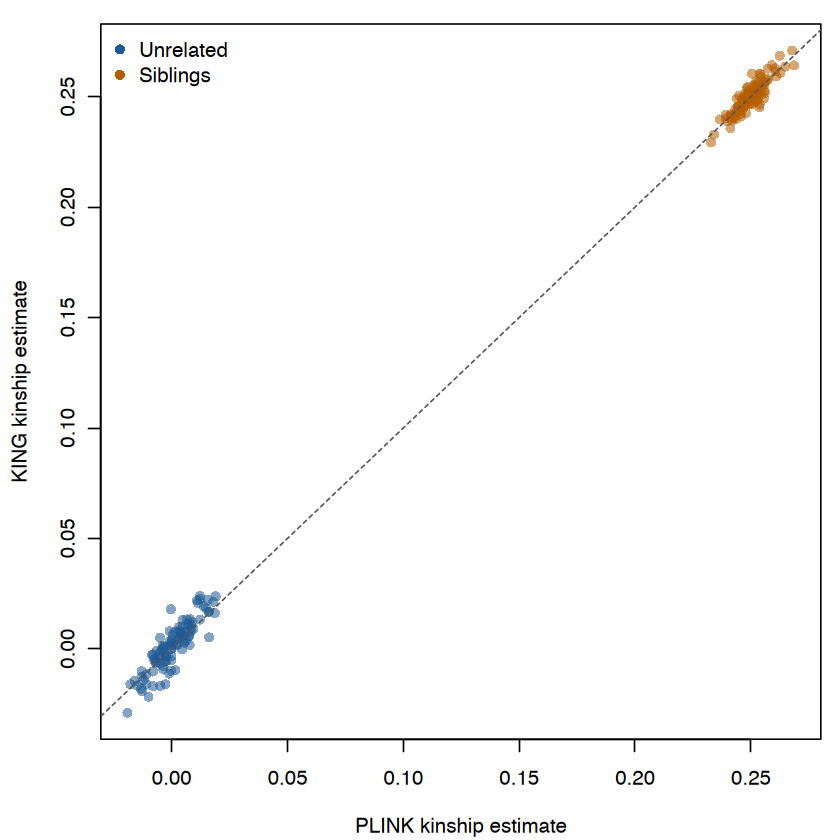

In [4]:
point_color <- ifelse(estimates$relationship == "Siblings", "#B55D00", "#1F5A94")
old_par <- par(mar = c(4.2, 4.2, 1.0, 0.8))
plot(
  estimates$PLINK, estimates$KING,
  xlab = "PLINK kinship estimate",
  ylab = "KING kinship estimate",
  pch = 16, col = adjustcolor(point_color, alpha.f = 0.55)
)
abline(0, 1, lty = 2, col = "#555555")
legend("topleft", c("Unrelated", "Siblings"),
  pch = 16, col = c("#1F5A94", "#B55D00"), bty = "n")
par(old_par)

## Why a local HMM is unnecessary here

A single marker cannot identify local IBD because the same genotype may arise by chance. Linked markers and an HMM resolve that local state.

Genome-wide kinship is an average. It does not require the position of each shared segment. Across many approximately independent markers, chance IBS approaches its expected baseline. The excess estimates average IBD.

## A+ extension

The simulation above used the correct $p_m$. In real data, a pooled allele frequency changes when the ancestry composition of the sample changes. KING-robust avoids that pooled baseline by using heterozygosity within the pair.

Use [Paper2Agent](https://github.com/jmiao24/Paper2Agent) with the [KING paper](https://www.cog-genomics.org/static/pdf/Manichaikuletal2010.pdf), then create one short R or Python notebook.

1. Simulate 100 fixed, unrelated population-A pairs at 1,000 independent SNPs under HWE with $p_A=0.30$.
2. Let the pooled background contain 0%, 50%, or 100% population B, where $p_B=0.60$.
3. For the same A--A pairs, compare the pooled-frequency moment above with KING-robust from Equation (9). Do not run the KING software.
4. Plot the estimates under the three background compositions.
5. Explain in two to four sentences which estimate changes when the background sample changes and why.

Submit the executed notebook as `king-numerical-example.html`. The figure, the two estimators, and the explanation must agree with the equations in the paper. The solution is intentionally omitted here.

## What to remember

- **Concept and intuition.** At one marker, IBS does not identify IBD. Across many markers, chance matches average out.
- **Insight behind the approach.** PLINK estimates the full IBD mixture from IBS counts. KING estimates kinship directly from genotype differences scaled by pair heterozygosity.
- **Connection.** In a homogeneous HWE population with many independent markers, both estimate $\phi=Z_1/4+Z_2/2$.

## Sources

- Pritchard, *An Owner's Guide to the Human Genome*, the linkage material in Chapters 4.1--4.2 and review Chapter 2.3. [Book page](https://web.stanford.edu/group/pritchardlab/HGbook.html)
- Gorroochurn, *Notes on Population Genetics*, Sections 7.2--7.3.
- Purcell et al. (2007), PLINK. [DOI](https://doi.org/10.1086/519795)
- Manichaikul et al. (2010), KING. [Paper](https://www.cog-genomics.org/static/pdf/Manichaikuletal2010.pdf)
- The simulation is an original course example. It uses 100 unrelated pairs, 100 sibling pairs, 5,000 independent SNPs, allele frequencies sampled uniformly from 0.10 to 0.50, and seed 8149.